# Sharqiyah Rental Monitor
## Exploratory Data Analysis of Eastern Province Rental Market (2019–2024)

# Phase 1 Overview

This part performs an exploratory data analysis (EDA) on the *Rental Indicators for Cities in the Eastern Province* dataset obtained from the Saudi Open Data Portal.

The goal of this analysis is to explore rental market patterns across cities in the Eastern Province between 2019 and 2024. The analysis focuses on identifying trends, detecting patterns in rental prices and transaction volumes, and understanding how rental markets vary across cities and property categories.

The insights obtained from this exploratory analysis will serve as a foundation for later stages of the project, where machine learning models such as clustering and LSTM forecasting will be applied to predict rental market trends.

## 1. Importing Required Libraries

In this section, the main Python libraries required for data analysis and visualization are imported.

- **Pandas** is used for data manipulation and data analysis.
- **NumPy** is used for numerical operations.
- **Matplotlib** and **Seaborn** are used to create visualizations that help us understand the dataset more clearly.

These libraries are commonly used in data science workflows and provide powerful tools for exploring and visualizing datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Loading the Dataset

The dataset used in this project contains rental indicators for cities in the Eastern Province of Saudi Arabia. The data includes information about rental transactions between 2019 and 2024.

To load the dataset, the file is uploaded directly into the notebook environment. After uploading, the dataset is read using the Pandas library and stored in a dataframe for further analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Rental indicators for cities in Eastern Province.csv to Rental indicators for cities in Eastern Province.csv


After uploading:

In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

/tmp/ipykernel_843/3452961890.py:1: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(list(uploaded.keys())[0])


,year,quarter,region_ar,city_ar,Category,total_deals,average
0,2019.0,1.0,المنطقة الشرقية,الاحساء,استديو - سكني,119.0,13884.95146
1,2019.0,1.0,المنطقة الشرقية,الجبيل,استديو - سكني,48.0,11644.44444
2,2019.0,1.0,المنطقة الشرقية,الخبر,استديو - سكني,328.0,13024.09722
3,2019.0,1.0,المنطقة الشرقية,الخفجي,استديو - سكني,3.0,10066.66667
4,2019.0,1.0,المنطقة الشرقية,الدمام,استديو - سكني,543.0,11609.30876


## 3. Dataset Overview

Understanding the structure of the dataset is an important first step in exploratory data analysis.
This section examines the dataset size, data types, and statistical summary of the variables.

This helps identify potential data quality issues and provides an initial understanding
of the rental market data.

In [ ]:
# dataset shape
df.shape

(1031004, 7)

In [ ]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031004 entries, 0 to 1031003
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         2383 non-null   float64
 1   quarter      2383 non-null   float64
 2   region_ar    2383 non-null   object 
 3   city_ar      2383 non-null   object 
 4   Category     2383 non-null   object 
 5   total_deals  2383 non-null   float64
 6   average      2383 non-null   float64
dtypes: float64(4), object(3)
memory usage: 55.1+ MB


In [ ]:
# statistical summary
df.describe()

,year,quarter,total_deals,average
count,2383.000000,2383.000000,2383.000000,2383.000000
mean,2021.751574,2.538397,751.944608,14316.467235
std,1.670977,1.115541,2957.008804,15720.228954
min,2019.000000,1.000000,1.000000,18.000000
25%,2020.000000,2.000000,5.000000,476.690655
50%,2022.000000,3.000000,39.000000,12415.153090
75%,2023.000000,4.000000,242.500000,19906.875280
max,2024.000000,4.000000,39212.000000,180000.000000


## 4. Data Preparation



### 4.1 	column renaming

The dataset contains some column names in Arabic format.
To simplify analysis and visualization, the column names are renamed to English.

This step improves readability and ensures compatibility with data analysis
and machine learning tools used later in the project.

In [ ]:
df.rename(columns={
    'year':'year',
    'quarter':'quarter',
    'region_ar':'region',
    'city_ar':'city',
    'Category':'category',
    'total_deals':'total_deals',
    'average':'average'
}, inplace=True)

df.columns

Index(['year', 'quarter', 'region', 'city', 'category', 'total_deals',
       'average'],
      dtype='object')

### 4.2 Remove completely empty rows



In [ ]:
df = df.dropna(how='all')

print("Shape after removing fully empty rows:", df.shape)

Shape after removing fully empty rows: (2383, 7)


### 4.3 Missing Values Analysis

Missing values can negatively impact data analysis and predictive modeling.
Therefore, it is important to examine whether the dataset contains any missing or incomplete entries.

The following analysis checks for missing values across all dataset columns.

In [ ]:
df.isnull().sum()

,0
year,0
quarter,0
region,0
city,0
category,0
total_deals,0
average,0


### 4.4 Duplicate Records Check

In [ ]:
df.duplicated().sum()

np.int64(0)

### 4.5 Translate Arabic text to English


In [ ]:
print(df["region"].dropna().unique())


['المنطقة الشرقية']


In [ ]:
print((df["city"].dropna().unique()))

['الاحساء' 'الجبيل' 'الخبر' 'الخفجي' 'الدمام' 'العيون' 'القطيف' 'النعيرية'
 'حفر الباطن' 'رأس تنورة' 'القيصومة' 'بقيق' 'الذيبية' 'قرية العليا'
 'الصداوى' 'قرية العليا - الرفيعه' 'مليجة' 'البويبيات' 'السعيرة' 'ام قليب'
 'ساموده' 'مناخ' 'يبرين' 'خبيراء' 'الرقعى الجديده' 'القلت' 'الحيراء'
 'النظيم' 'معرج السوبان' 'درب الابل']


In [ ]:
print(sorted(df["category"].dropna().unique()))

['استديو - سكني', 'دوبلاكس - سكني', 'دور - سكني', 'شقة - سكني', 'فيلا - سكني', 'محل - تجاري', 'معرض تجاري - تجاري', 'مكتب - تجاري']


In [ ]:
region_map = {
    "المنطقة الشرقية": "Eastern Province"
}

city_translation = {
    'الاحساء': 'Al Ahsa',
    'الجبيل': 'Al Jubail',
    'الخبر': 'Al Khobar',
    'الخفجي': 'Al Khafji',
    'الدمام': 'Dammam',
    'العيون': 'Al Oyoun',
    'القطيف': 'Al Qatif',
    'النعيرية': 'Al Nairyah',
    'حفر الباطن': 'Hafar Al Batin',
    'رأس تنورة': 'Ras Tanura',
    'القيصومة': 'Al Qaisumah',
    'بقيق': 'Buqayq',
    'الذيبية': 'Al Dhibiyah',
    'قرية العليا': 'Qaryat Al Ulya',
    'الصداوى': 'Al Sadowi',
    'قرية العليا - الرفيعه': 'Qaryat Al Ulya - Al Rafi\'ah',
    'مليجة': 'Mulayjah',
    'البويبيات': 'Al Buwaybiyat',
    'السعيرة': 'Al Su\'ayrah',
    'ام قليب': 'Umm Ghalib',
    'ساموده': 'Samudah',
    'مناخ': 'Manakh',
    'يبرين': 'Yabrin',
    'خبيراء': 'Khubayra',
    'الرقعى الجديده': 'Al Raqi Al Jadidah',
    'القلت': 'Al Qalat',
    'الحيراء': 'Al Haira',
    'النظيم': 'Al Nadhim',
    'معرج السوبان': 'Maarij Al Suban',
    'درب الابل': 'Darb Al Ibl'
}

category_translation = {
    'استديو - سكني': 'Studio - Residential',
    'دوبلاكس - سكني': 'Duplex - Residential',
    'دور - سكني': 'Floor - Residential',
    'شقة - سكني': 'Apartment - Residential',
    'فيلا - سكني': 'Villa - Residential',
    'محل - تجاري': 'Shop - Commercial',
    'معرض تجاري - تجاري': 'Showroom - Commercial',
    'مكتب - تجاري': 'Office - Commercial'
}


In [ ]:
df["region"] = df["region"].map(region_map)
df["city"] = df["city"].map(city_translation)
df["category"] = df["category"].map(category_translation)

In [ ]:
df.head()

,year,quarter,region,city,category,total_deals,average
0,2019.0,1.0,Eastern Province,Al Ahsa,Studio - Residential,119.0,13884.95146
1,2019.0,1.0,Eastern Province,Al Jubail,Studio - Residential,48.0,11644.44444
2,2019.0,1.0,Eastern Province,Al Khobar,Studio - Residential,328.0,13024.09722
3,2019.0,1.0,Eastern Province,Al Khafji,Studio - Residential,3.0,10066.66667
4,2019.0,1.0,Eastern Province,Dammam,Studio - Residential,543.0,11609.30876


### 4.6 	Date formatting



In [ ]:
# filter for ONLY Residential properties
df = df[df['category'].str.contains('Residential', na=False)]

df["total_deals"] = df["total_deals"].astype(int)

# Combine year and quarter directly into a true Time-Series Datetime object
date_strings = df['year'].astype(int).astype(str) + 'Q' + df['quarter'].astype(int).astype(str)
df['Date'] = pd.to_datetime(date_strings)

# Drop the old year and quarter columns
df = df.drop(columns=['year', 'quarter'])

df = df.reset_index(drop=True)


/tmp/ipykernel_843/1528605777.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(date_strings)


In [ ]:

print("Remaining Categories:", df['category'].unique())
print("Final clean shape for EDA:", df.shape)

Remaining Categories: ['Studio - Residential' 'Duplex - Residential' 'Floor - Residential'
 'Apartment - Residential' 'Villa - Residential']
Final clean shape for EDA: (1577, 6)


In [ ]:

df.head(100)

,region,city,category,total_deals,average,Date
0,Eastern Province,Al Ahsa,Studio - Residential,119,13884.95146,2019-01-01
1,Eastern Province,Al Jubail,Studio - Residential,48,11644.44444,2019-01-01
2,Eastern Province,Al Khobar,Studio - Residential,328,13024.09722,2019-01-01
3,Eastern Province,Al Khafji,Studio - Residential,3,10066.66667,2019-01-01
4,Eastern Province,Dammam,Studio - Residential,543,11609.30876,2019-01-01
...,...,...,...,...,...,...
95,Eastern Province,Buqayq,Villa - Residential,1,90000.00000,2019-04-01
96,Eastern Province,Al Ahsa,Studio - Residential,166,11965.43624,2019-07-01
97,Eastern Province,Al Jubail,Studio - Residential,47,12674.46809,2019-07-01
98,Eastern Province,Al Khobar,Studio - Residential,313,13324.96454,2019-07-01


##5.	Exploratory Data Analysis


### 5.1 Dataset Overview and 5.2 Missing Values Analysis

In [ ]:
# 1.1 Dataset Overview
print("Dataset Shape:", df.shape)
display(df.describe())

# 1.2 Missing Values Analysis
print("\\nMissing Values:\\n", df.isnull().sum())

Dataset Shape: (1577, 6)


,total_deals,average,Date
count,1577.000000,1577.000000,1577
mean,964.948637,21415.764457,2022-02-07 13:40:54.026632960
min,1.000000,4800.000000,2019-01-01 00:00:00
25%,6.000000,12508.448410,2020-10-01 00:00:00
50%,39.000000,16706.028570,2022-04-01 00:00:00
75%,279.000000,25000.000000,2023-07-01 00:00:00
max,39212.000000,180000.000000,2024-10-01 00:00:00
std,3572.688277,14979.277434,NaN


\nMissing Values:\n region         0
city           0
category       0
total_deals    0
average        0
Date           0
dtype: int64


### 5.3 Distribution of Rental Prices

To better understand the rental market, we examine the distribution of average rental prices.
A histogram is used to visualize how rental prices are distributed across the dataset.

This analysis helps identify the general price range, potential skewness in the data,
and possible outliers.

In [ ]:
import plotly.express as px

fig_dist = px.histogram(df, x="average",
                   title="Distribution of Residential Rental Prices",
                   labels={"average": "Average Rental Price (SAR)"},
                   marginal="box",
                   color_discrete_sequence=['#1f77b4'])


fig_dist.show()

### 5.4	Outlier Detection

In [ ]:
# Boxplot for Prices
fig_out_price = px.box(df, y="average",
                       title="Outlier Detection: Rental Prices",
                       labels={"average": "Average Price (SAR)"})
fig_out_price.show()

# Boxplot for Total Deals
fig_out_deals = px.box(df, y="total_deals",
                       title="Outlier Detection: Transaction Volumes (Total Deals)",
                       labels={"total_deals": "Number of Deals"})
fig_out_deals.show()

### 5.5 Rental Transactions by City



In [ ]:
# Group by city and sum the deals, then sort from highest to lowest
city_deals = df.groupby('city')['total_deals'].sum().reset_index().sort_values('total_deals', ascending=False)

fig_city_deals = px.bar(city_deals, x='city', y='total_deals',
                        title="Market Demand: Total Rental Transactions by City",
                        labels={'city': 'City', 'total_deals': 'Total Number of Deals'},
                        text_auto='.2s', # Adds the numbers on top of the bars
                        color='total_deals', color_continuous_scale='Blues')
fig_city_deals.show()

### 5.6 Average Rental Price by City


In [ ]:
# Group by city and calculate the average price
city_price = df.groupby('city')['average'].mean().reset_index().sort_values('average', ascending=False)

fig_city_price = px.bar(city_price, x='city', y='average',
                        title="Affordability: Average Rental Price by City",
                        labels={'city': 'City', 'average': 'Average Price (SAR)'},
                        color='average', color_continuous_scale='Reds')
fig_city_price.show()

### 5.7 Property Category Analysis


In [ ]:
# Group by category to see average prices
cat_price = df.groupby('category')['average'].mean().reset_index().sort_values('average', ascending=False)

fig_cat_price = px.bar(cat_price, x='category', y='average',
                       title="Average Rental Price by Property Category",
                       labels={'category': 'Property Type', 'average': 'Average Price (SAR)'},
                       color='category') # Gives each property type a unique color
fig_cat_price.show()

### 5.8 Correlation Analysis


In [ ]:
fig_scatter = px.scatter(df, x="total_deals", y="average",
                         color="category", hover_data=['city'],
                         title="Correlation: Total Deals vs. Average Price",
                         labels={"total_deals": "Total Transactions (Demand)", "average": "Average Price (SAR)"},
                         opacity=0.7)
fig_scatter.show()

### 5.9 Rental Price Trends Over Time


In [ ]:
# Group by Date to see the market average over time
time_trend = df.groupby('Date')['average'].mean().reset_index()

fig_trend = px.line(time_trend, x='Date', y='average', markers=True,
                    title="Rental Price Trends Over Time (2019-2024)",
                    labels={'Date': 'Year & Quarter', 'average': 'Average Price (SAR)'},
                    line_shape='spline') # Makes the line curve smoothly
fig_trend.show()

In [ ]:
# Save the cleaned dataset without the index numbers
df.to_csv('cleaned_sharqiyah_rentals.csv', index=False)

## 6. Advanced  Data Preprocessing


### 6.1 Handling Categorical Variables


In [ ]:
import joblib

# Create a copy for preprocessing to preserve the original EDA dataframe
df_prep = df.copy()

# One-Hot Encoding: Transforming 'city' and 'category' into binary vectors
# We use drop_first=False here to ensure all categories are explicitly represented for the LSTM
df_prep = pd.get_dummies(
    df_prep,
    columns=["city", "category"],
    prefix=["city", "cat"]
)

# Save the column structure for model deployment (Streamlit integration)
joblib.dump(df_prep.columns.tolist(), "encoder_columns.joblib")

print(f"Total features after encoding: {df_prep.shape[1]}")
df_prep.head()

Total features after encoding: 39


,region,total_deals,average,Date,city_Al Ahsa,city_Al Buwaybiyat,city_Al Dhibiyah,city_Al Haira,city_Al Jubail,city_Al Khafji,...,city_Qaryat Al Ulya - Al Rafi'ah,city_Ras Tanura,city_Samudah,city_Umm Ghalib,city_Yabrin,cat_Apartment - Residential,cat_Duplex - Residential,cat_Floor - Residential,cat_Studio - Residential,cat_Villa - Residential
0,Eastern Province,119,13884.95146,2019-01-01,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,Eastern Province,48,11644.44444,2019-01-01,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,Eastern Province,328,13024.09722,2019-01-01,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,Eastern Province,3,10066.66667,2019-01-01,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,Eastern Province,543,11609.30876,2019-01-01,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


### 6.2 Handling Outliers & Skewness


In [ ]:
from scipy.stats.mstats import winsorize
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Winsorization for Total Deals: Capping at the 1st and 99th percentiles
df_prep["total_deals_wins"] = winsorize(df_prep["total_deals"], limits=[0.01, 0.01])

# 2. Log Transformation for Average Price to normalize right-skewness
# Formula applied: $y' = \log(y + 1)$
df_prep["log_average"] = np.log1p(df_prep["average"])

# Visualization: Comparing Distributions
fig_hist = make_subplots(rows=1, cols=2, subplot_titles=("Original Rental Price", "Log-Transformed Price"))
fig_hist.add_trace(go.Histogram(x=df_prep["average"], name="Original"), row=1, col=1)
fig_hist.add_trace(go.Histogram(x=df_prep["log_average"], name="Log-Transformed"), row=1, col=2)
fig_hist.update_layout(title_text="Normalization of Rental Price Distribution", showlegend=False)
fig_hist.show()

### 6.3	Feature Selection


In [ ]:
# Extracting temporal features
df_prep["Date"] = pd.to_datetime(df_prep["Date"])
df_prep["year"] = df_prep["Date"].dt.year
df_prep["quarter"] = df_prep["Date"].dt.quarter

# Defining the Feature Matrix (X) and Target Variable (y)
# We drop 'average' (since we use log), 'Date' (decomposed), and 'region' (constant)
drop_cols = ["average", "log_average", "Date", "region"]
X = df_prep.drop(columns=[col for col in drop_cols if col in df_prep.columns])
y = df_prep["log_average"]

print(f"Final Input Shape: {X.shape}")

Final Input Shape: (1577, 39)


# Experimental Analysis and Modeling

# **Sharqiyah Rental Monitor**: Regional Analysis & Long-Term Forecasting of Eastern Province Housing Trends (2019–2024)

---
## Phase 2 Overview

This part represents Phase 2 of the Sharqiyah Rental Monitor project. Building upon the Exploratory Data Analysis (EDA) and advanced data preprocessing completed in Phase 1. Here we are focuse on the experimental analysis and predictive modeling of real estate prices in the Eastern Province.

Because the processed dataset is fundamentally tabular and driven by categorical features (City, Property Type), we have selected two state-of-the-art Gradient Boosting frameworks for this application.

# 1. Setup & Splitting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib

# 1. Load Data
df = pd.read_csv('/content/drive/MyDrive/cleaned_sharqiyah_rentals.csv')

# 2. Convert Date to actual numerical time features
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['quarter'] = df['Date'].dt.quarter

# 3. Define Features (Drop average and the old Date string)
X = df.drop(['average', 'Date'], axis=1)
y = np.log1p(df['average'])

# 4. The Magic Fix: Separate Text from Numbers
categorical_cols = ['region', 'city', 'category']
numerical_cols = ['total_deals', 'year', 'quarter']

# Only encode the text. 'passthrough' tells it to leave the numbers as pure math!
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Apply the transformation
X_encoded = preprocessor.fit_transform(X)

# 5. Save the preprocessor object (Streamlit NEEDS this exact file!)
joblib.dump(preprocessor, '/content/drive/MyDrive/encoder.pkl')

# 6. Split the data and save for the models
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Save the splits to Drive so CatBoost can train on them
pd.DataFrame(X_train).to_csv('/content/drive/MyDrive/X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('/content/drive/MyDrive/X_test.csv', index=False)
pd.DataFrame(y_train).to_csv('/content/drive/MyDrive/y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('/content/drive/MyDrive/y_test.csv', index=False)

print("Data successfully cleaned, transformed, and saved!")

Data successfully cleaned, transformed, and saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. XGBoost Modeling

In [ ]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize model
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",  # regression task
    random_state=42                # for reproducibility
)

# Define parameter grid for tuning
param_grid = {
    "n_estimators": [100, 200],   # number of trees
    "max_depth": [3, 5],          # tree depth
    "learning_rate": [0.05, 0.1], # step size
    "subsample": [0.8, 1.0]       # sample ratio
}

# Apply GridSearch with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,                                 # 3-fold cross validation
    scoring="neg_mean_squared_error",      # optimization metric
    verbose=1,
    n_jobs=-1                             # use all CPU cores
)

# Train model on training data
grid_search.fit(X_train, y_train)

# Extract best model
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [ ]:
# Predict on test data
y_pred = best_model.predict(X_test)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)         # average error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # penalizes large errors
r2 = r2_score(y_test, y_pred)                    # goodness of fit

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.16635252338743622
RMSE: 0.25171832141967676
R²: 0.787023953522069


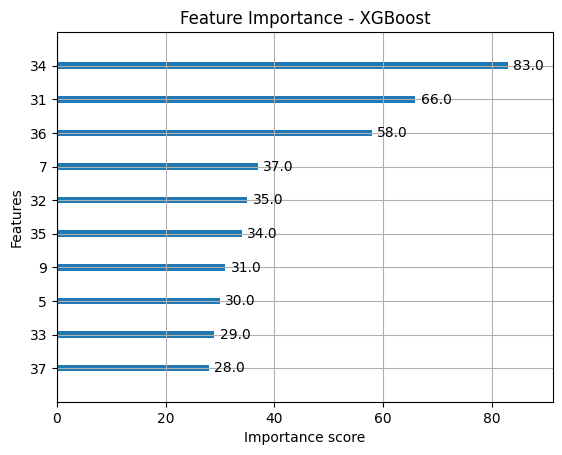

In [ ]:
# Since target was log-transformed, convert predictions back
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

# Show most important features used by the model
xgb.plot_importance(best_model, max_num_features=10)
plt.title("Feature Importance - XGBoost")
plt.show()

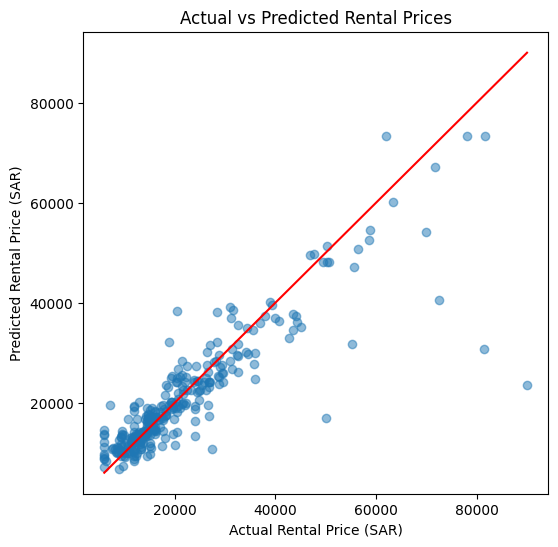

['/content/drive/MyDrive/xgboost_model.pkl']

In [ ]:
# Compare real vs predicted rental prices
plt.figure(figsize=(6,6))

plt.scatter(y_test_real, y_pred_real, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    color='red'
)

plt.xlabel("Actual Rental Price (SAR)")
plt.ylabel("Predicted Rental Price (SAR)")
plt.title("Actual vs Predicted Rental Prices")

plt.show()

# Save model
joblib.dump(best_model, "/content/drive/MyDrive/xgboost_model.pkl")

In [ ]:
print("\n===== FINAL RESULTS =====")
print("Best Parameters:", grid_search.best_params_)
print("MAE =", mae)
print("RMSE =", rmse)
print("R2 =", r2)


===== FINAL RESULTS =====
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
MAE = 0.16635252338743622
RMSE = 0.25171832141967676
R2 = 0.787023953522069


# 3. CatBoost Modeling

### Install & Import Libraries

In [ ]:
!pip install catboost

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


### Load Data

In [ ]:
X_train = pd.read_csv("/content/drive/MyDrive/X_train.csv")
X_test = pd.read_csv("/content/drive/MyDrive/X_test.csv")
y_train = pd.read_csv("/content/drive/MyDrive/y_train.csv").squeeze()
y_test = pd.read_csv("/content/drive/MyDrive/y_test.csv").squeeze()

### Baseline CatBoost Model

In [ ]:
cat_model = CatBoostRegressor(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.14696782493865213
RMSE: 0.2366516062904121
R2: 0.8117564865376724


### Hyperparameter Tuning

In [ ]:
param_grid = {
    'iterations': [200, 500, 800],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

cat = CatBoostRegressor(verbose=0, random_state=42)

grid_search = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'depth': 4, 'iterations': 500, 'learning_rate': 0.05}


### Evaluate Best Model

In [ ]:
y_pred_best = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("Best MAE:", mae)
print("Best RMSE:", rmse)
print("Best R2:", r2)

Best MAE: 0.16397359929621932
Best RMSE: 0.24856485407729145
Best R2: 0.792326754680108


### Save Final Model

In [ ]:
joblib.dump(best_model, "catboost_model.pkl")

['catboost_model.pkl']

### Training Error/Loss Curve

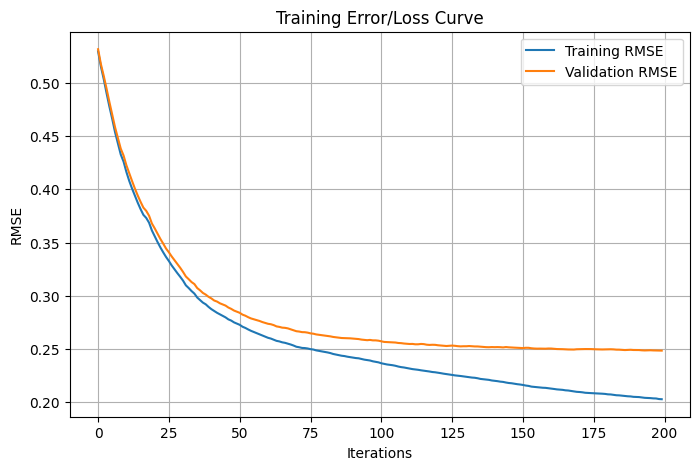

In [ ]:

best_cat = CatBoostRegressor(
    iterations=grid_search.best_params_['iterations'],
    depth=grid_search.best_params_['depth'],
    learning_rate=grid_search.best_params_['learning_rate'],
    verbose=0,
    random_state=42
)

best_cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

results = best_cat.get_evals_result()


plt.figure(figsize=(8,5))
plt.plot(results['learn']['RMSE'], label='Training RMSE')
plt.plot(results['validation']['RMSE'], label='Validation RMSE')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('Training Error/Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

### Actual vs Predicted Plot

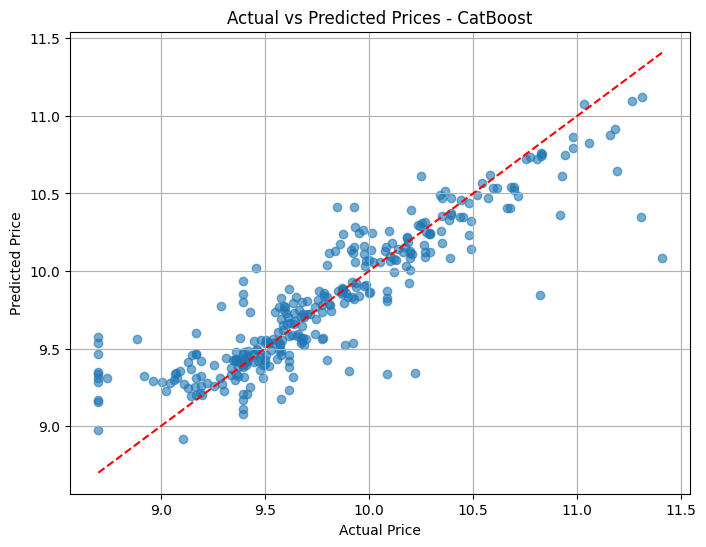

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - CatBoost")
plt.grid(True)
plt.show()

### Final Results for CatBoost model

In [ ]:
print("===== FINAL RESULTS =====")
print("Best Parameters:", grid_search.best_estimator_)
print("MAE =", mae)
print("RMSE =", rmse)
print("R2 =", r2)

===== FINAL RESULTS =====
Best Parameters: CatBoostRegressor(depth=8, iterations=200, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)
MAE = 0.16397359929621932
RMSE = 0.24856485407729145
R2 = 0.792326754680108


In [ ]:
import pandas as pd

table = pd.DataFrame({
    'Parameter': ['iterations', 'depth', 'learning_rate'],
    'Values Tested': ['200, 500, 800', '4, 6, 8', '0.01, 0.05, 0.1'],
    'Best Value': [
        grid_search.best_params_['iterations'],
        grid_search.best_params_['depth'],
        grid_search.best_params_['learning_rate']
    ]
})

print("Table: CatBoost Hyperparameter Grid")
display(table)

Table: CatBoost Hyperparameter Grid


,Parameter,Values Tested,Best Value
0,iterations,"200, 500, 800",200.00
1,depth,"4, 6, 8",8.00
2,learning_rate,"0.01, 0.05, 0.1",0.05


# 4. Final Evaluation
* Compare models head-to-head using MAE, RMSE, and R-squared metrics.

In [ ]:
import pandas as pd

# Create comparison table using your results
comparison_table = pd.DataFrame({
    "Model": ["XGBoost", "CatBoost"],
    "MAE": [0.166, 0.163],
    "RMSE": [0.252, 0.247],
    "R²": [0.787, 0.794]
})

# Round values for clean display
comparison_table = comparison_table.round(3)

comparison_table

,Model,MAE,RMSE,R²
0,XGBoost,0.166,0.252,0.787
1,CatBoost,0.163,0.247,0.794


CatBoost slightly outperforms XGBoost across all evaluation metrics, with lower errors and higher R². Therefore, it is selected as the final model.

# 5. Model Export

* Save the **optimal** predictive model and its encoders as `.pkl` files for live integration into our investor-facing Streamlit web dashboard.

In [ ]:
joblib.dump(best_cat, "/content/drive/MyDrive/final_model.pkl")
print("Final model saved successfully!")
joblib.dump(X_train.columns.tolist(), "/content/drive/MyDrive/encoder_columns.pkl")
print("Encoder saved successfully!")

Final model saved successfully!
Encoder saved successfully!
